In [ ]:
!pip install xgboost shap pandas matplotlib scikit-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
MODELS_DIR = "/content/drive/MyDrive/Chotot Project/models"
TRANSFORM_DATA_DIR = "/content/drive/MyDrive/Chotot Project/TransformData"
RAW_DATA_DIR = "/content/drive/MyDrive/Chotot Project/RawData"

In [ ]:
"""
Real Estate Price Prediction - Enhanced with SHAP Explanations
Adds XGBoost model loading and SHAP-based feature importance analysis
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Linear Regression Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    HuberRegressor,
    SGDRegressor,
    PassiveAggressiveRegressor
)
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR, LinearSVR
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
import lightgbm as lgb

# SHAP for model explanations
import shap

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


class RealEstatePricePredictor:
    """
    Comprehensive Real Estate Price Prediction System with SHAP Explanations
    """

    def __init__(self, data_path):
        """
        Initialize the predictor

        Parameters:
        -----------
        data_path : str
            Path to the CSV file containing real estate data
        """
        self.data_path = data_path
        self.df = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.preprocessor = None
        self.models = {}
        self.results = {}
        self.shap_explainers = {}
        self.shap_values = {}

        # Column lists will be populated after loading data
        self.numeric_features = None
        self.categorical_features = None

        self.target = 'log_price'

    def load_data(self):
        """Load and perform initial data exploration"""
        print("=" * 80)
        print("LOADING DATA")
        print("=" * 80)

        self.df = pd.read_csv(self.data_path)
        print(f"Dataset shape: {self.df.shape}")
        print(f"\nTarget variable (log_price) statistics:")
        print(self.df[self.target].describe())
        print(f"\nMissing values summary:")
        missing = self.df.isnull().sum()
        missing = missing[missing > 0].sort_values(ascending=False)
        if len(missing) > 0:
            print(missing)
        else:
            print("No missing values!")

        # Automatically detect feature types
        self._detect_features()

        return self

    def _detect_features(self):
        """Automatically detect numeric and categorical features"""
        # Get all columns except target
        all_columns = [col for col in self.df.columns if col != self.target]

        # Detect numeric features (int64, float64)
        self.numeric_features = self.df[all_columns].select_dtypes(
            include=['int64', 'float64', 'int32', 'float32']
        ).columns.tolist()

        # Detect categorical features (object type, bool, category)
        self.categorical_features = self.df[all_columns].select_dtypes(
            include=['object', 'category', 'bool']
        ).columns.tolist()

        print(f"\n{'=' * 80}")
        print("FEATURE DETECTION")
        print(f"{'=' * 80}")
        print(f"Numeric features ({len(self.numeric_features)}): {self.numeric_features}")
        print(f"\nCategorical features ({len(self.categorical_features)}): {self.categorical_features}")

        # Validate that we found features
        if len(self.numeric_features) == 0 and len(self.categorical_features) == 0:
            raise ValueError("No features detected! Please check your data.")

        return self

    def preprocess_data(self, test_size=0.2):
        """
        Preprocess the data including handling missing values, encoding, and scaling

        Parameters:
        -----------
        test_size : float
            Proportion of dataset to include in test split
        """
        print("\n" + "=" * 80)
        print("PREPROCESSING DATA")
        print("=" * 80)

        # Validate that features have been detected
        if self.numeric_features is None or self.categorical_features is None:
            raise ValueError("Features not detected. Please run load_data() first.")

        # Verify all features exist in the dataframe
        missing_numeric = [f for f in self.numeric_features if f not in self.df.columns]
        missing_categorical = [f for f in self.categorical_features if f not in self.df.columns]

        if missing_numeric:
            print(f"WARNING: Numeric features not found in data: {missing_numeric}")
            self.numeric_features = [f for f in self.numeric_features if f in self.df.columns]

        if missing_categorical:
            print(f"WARNING: Categorical features not found in data: {missing_categorical}")
            self.categorical_features = [f for f in self.categorical_features if f in self.df.columns]

        # Convert categorical columns to string to handle mixed types
        print("\nConverting categorical features to string type...")
        for col in self.categorical_features:
            if col in self.df.columns:
                self.df[col] = self.df[col].astype(str)

        # Separate features and target
        X = self.df.drop(columns=[self.target])
        y = self.df[self.target]

        # Split data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=RANDOM_STATE
        )

        print(f"Training set size: {self.X_train.shape}")
        print(f"Test set size: {self.X_test.shape}")

        # Create preprocessing pipelines
        transformers = []

        # Add numeric transformer if we have numeric features
        if len(self.numeric_features) > 0:
            numeric_transformer = Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler())
            ])
            transformers.append(('num', numeric_transformer, self.numeric_features))
            print(f"\nNumeric features ({len(self.numeric_features)}): {self.numeric_features[:5]}...")

        # Add categorical transformer if we have categorical features
        if len(self.categorical_features) > 0:
            categorical_transformer = Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
            ])
            transformers.append(('cat', categorical_transformer, self.categorical_features))
            print(f"Categorical features ({len(self.categorical_features)}): {self.categorical_features[:5]}...")

        # Combine transformers
        if len(transformers) == 0:
            raise ValueError("No valid features found for preprocessing!")

        self.preprocessor = ColumnTransformer(
            transformers=transformers,
            remainder='drop'
        )

        print("\nPreprocessing pipeline created successfully!")

        return self

    def define_models(self):
        """Define all regression models to be trained"""
        print("\n" + "=" * 80)
        print("DEFINING MODELS")
        print("=" * 80)

        self.models = {
            # Linear Models
            'Linear Regression': LinearRegression(),
            'Ridge': Ridge(random_state=RANDOM_STATE),
            'Lasso': Lasso(random_state=RANDOM_STATE),
            'ElasticNet': ElasticNet(random_state=RANDOM_STATE),
            'Bayesian Ridge': BayesianRidge(),
            'Huber Regressor': HuberRegressor(),
            'SGD Regressor': SGDRegressor(random_state=RANDOM_STATE),

            # Kernel-based Models
            'SVR (RBF)': SVR(kernel='rbf'),
            'SVR (Linear)': LinearSVR(random_state=RANDOM_STATE),

            # Tree-based Models
            'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
            'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=RANDOM_STATE),

            # Gradient Boosting Variants
            'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
            'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),

            # Other Models
            'KNN': KNeighborsRegressor(n_jobs=-1),
        }

        print(f"Total models defined: {len(self.models)}")
        for model_name in self.models.keys():
            print(f"  - {model_name}")

        return self

    def train_and_evaluate(self):
        """Train all models and evaluate their performance"""
        print("\n" + "=" * 80)
        print("TRAINING AND EVALUATING MODELS")
        print("=" * 80)

        for model_name, model in self.models.items():
            print(f"\n{'=' * 40}")
            print(f"Training: {model_name}")
            print(f"{'=' * 40}")

            try:
                # Create pipeline
                pipeline = Pipeline([
                    ('preprocessor', self.preprocessor),
                    ('model', model)
                ])

                # Train
                pipeline.fit(self.X_train, self.y_train)

                # Predict
                y_train_pred = pipeline.predict(self.X_train)
                y_test_pred = pipeline.predict(self.X_test)

                # Calculate metrics
                train_metrics = self._calculate_metrics(self.y_train, y_train_pred)
                test_metrics = self._calculate_metrics(self.y_test, y_test_pred)

                # Cross-validation score
                cv_scores = cross_val_score(
                    pipeline, self.X_train, self.y_train,
                    cv=5, scoring='r2', n_jobs=-1
                )

                # Store results
                self.results[model_name] = {
                    'pipeline': pipeline,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics,
                    'cv_r2_mean': cv_scores.mean(),
                    'cv_r2_std': cv_scores.std()
                }

                # Print results
                print(f"Training R²: {train_metrics['r2']:.4f}")
                print(f"Test R²: {test_metrics['r2']:.4f}")
                print(f"Test RMSE: {test_metrics['rmse']:.4f}")
                print(f"Test MAE: {test_metrics['mae']:.4f}")
                print(f"CV R² (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

            except Exception as e:
                print(f"Error training {model_name}: {str(e)}")
                continue

        print("\n" + "=" * 80)
        print("TRAINING COMPLETED")
        print("=" * 80)

        return self

    def _calculate_metrics(self, y_true, y_pred):
        """Calculate evaluation metrics"""
        return {
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae': mean_absolute_error(y_true, y_pred),
            'r2': r2_score(y_true, y_pred),
            'mape': mean_absolute_percentage_error(y_true, y_pred) * 100
        }

    def display_results_summary(self):
        """Display comprehensive results summary"""
        print("\n" + "=" * 80)
        print("RESULTS SUMMARY")
        print("=" * 80)

        # Create summary dataframe
        summary_data = []
        for model_name, result in self.results.items():
            summary_data.append({
                'Model': model_name,
                'Train R²': result['train_metrics']['r2'],
                'Test R²': result['test_metrics']['r2'],
                'CV R² (mean)': result['cv_r2_mean'],
                'Test RMSE': result['test_metrics']['rmse'],
                'Test MAE': result['test_metrics']['mae'],
                'Test MAPE (%)': result['test_metrics']['mape']
            })

        summary_df = pd.DataFrame(summary_data)
        summary_df = summary_df.sort_values('Test R²', ascending=False)

        print("\n" + summary_df.to_string(index=False))

        # Best model
        best_model_name = summary_df.iloc[0]['Model']
        best_r2 = summary_df.iloc[0]['Test R²']
        print(f"\n{'=' * 80}")
        print(f"BEST MODEL: {best_model_name} (Test R² = {best_r2:.4f})")
        print(f"{'=' * 80}")

        return summary_df

    def grid_search_top_models(self, top_n=3):
        """
        Perform grid search on top N models

        Parameters:
        -----------
        top_n : int
            Number of top models to tune
        """
        print("\n" + "=" * 80)
        print(f"GRID SEARCH ON TOP {top_n} MODELS")
        print("=" * 80)

        # Get top models
        summary_data = []
        for model_name, result in self.results.items():
            summary_data.append({
                'Model': model_name,
                'Test R²': result['test_metrics']['r2']
            })
        summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
        top_models = summary_df.head(top_n)['Model'].tolist()

        # Define parameter grids
        param_grids = {
            'Ridge': {
                'model__alpha': [0.1, 1.0, 10.0, 100.0],
                'model__solver': ['auto', 'svd', 'lsqr']
            },
            'Lasso': {
                'model__alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
                'model__max_iter': [1000, 5000]
            },
            'ElasticNet': {
                'model__alpha': [0.001, 0.01, 0.1, 1.0],
                'model__l1_ratio': [0.2, 0.5, 0.8],
                'model__max_iter': [1000, 5000]
            },
            'Random Forest': {
                'model__n_estimators': [100, 200],
                'model__max_depth': [10, 20, 30],
                'model__min_samples_split': [2, 5, 10],
                'model__min_samples_leaf': [1, 2, 4]
            },
            'Gradient Boosting': {
                'model__n_estimators': [100, 200],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__max_depth': [3, 5, 7],
                'model__min_samples_split': [2, 5]
            },
            'XGBoost': {
                'model__n_estimators': [100, 200],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__max_depth': [3, 5, 7],
                'model__subsample': [0.8, 1.0],
                'model__colsample_bytree': [0.8, 1.0]
            },
            'LightGBM': {
                'model__n_estimators': [100, 200],
                'model__learning_rate': [0.01, 0.05, 0.1],
                'model__max_depth': [3, 5, 7, -1],
                'model__num_leaves': [31, 50, 100],
                'model__subsample': [0.8, 1.0]
            },
            'SVR (RBF)': {
                'model__C': [0.1, 1, 10, 100],
                'model__gamma': ['scale', 'auto', 0.001, 0.01],
                'model__epsilon': [0.01, 0.1, 0.2]
            },
            'KNN': {
                'model__n_neighbors': [3, 5, 7, 9, 11],
                'model__weights': ['uniform', 'distance'],
                'model__p': [1, 2]
            }
        }

        tuned_results = {}

        for model_name in top_models:
            if model_name not in param_grids:
                print(f"\nSkipping {model_name} - no parameter grid defined")
                continue

            print(f"\n{'=' * 40}")
            print(f"Grid Search: {model_name}")
            print(f"{'=' * 40}")

            try:
                # Create pipeline
                pipeline = Pipeline([
                    ('preprocessor', self.preprocessor),
                    ('model', self.models[model_name])
                ])

                # Grid search
                grid_search = GridSearchCV(
                    pipeline,
                    param_grids[model_name],
                    cv=5,
                    scoring='r2',
                    n_jobs=-1,
                    verbose=1
                )

                grid_search.fit(self.X_train, self.y_train)

                # Evaluate best model
                y_train_pred = grid_search.predict(self.X_train)
                y_test_pred = grid_search.predict(self.X_test)

                train_metrics = self._calculate_metrics(self.y_train, y_train_pred)
                test_metrics = self._calculate_metrics(self.y_test, y_test_pred)

                tuned_results[model_name] = {
                    'best_params': grid_search.best_params_,
                    'best_score': grid_search.best_score_,
                    'pipeline': grid_search.best_estimator_,
                    'train_metrics': train_metrics,
                    'test_metrics': test_metrics
                }

                print(f"\nBest Parameters: {grid_search.best_params_}")
                print(f"Best CV R²: {grid_search.best_score_:.4f}")
                print(f"Test R²: {test_metrics['r2']:.4f}")
                print(f"Test RMSE: {test_metrics['rmse']:.4f}")

            except Exception as e:
                print(f"Error in grid search for {model_name}: {str(e)}")
                continue

        # Display tuned results
        print("\n" + "=" * 80)
        print("TUNED MODELS SUMMARY")
        print("=" * 80)

        tuned_summary = []
        for model_name, result in tuned_results.items():
            tuned_summary.append({
                'Model': model_name,
                'Best CV R²': result['best_score'],
                'Test R²': result['test_metrics']['r2'],
                'Test RMSE': result['test_metrics']['rmse'],
                'Test MAE': result['test_metrics']['mae']
            })

        if tuned_summary:
            tuned_df = pd.DataFrame(tuned_summary).sort_values('Test R²', ascending=False)
            print("\n" + tuned_df.to_string(index=False))

            # Save best tuned model
            best_tuned_name = tuned_df.iloc[0]['Model']
            self.best_model = tuned_results[best_tuned_name]['pipeline']
            self.best_model_name = f"{best_tuned_name} (Tuned)"

            print(f"\n{'=' * 80}")
            print(f"BEST TUNED MODEL: {best_tuned_name}")
            print(f"Best Parameters: {tuned_results[best_tuned_name]['best_params']}")
            print(f"{'=' * 80}")

        return tuned_results

    # ==================== SHAP EXPLANATION METHODS ====================

    def initialize_shap_explainer(self, model_name=None, sample_size=100):
        """
        Initialize SHAP explainer for a specific model

        Parameters:
        -----------
        model_name : str, optional
            Name of the model to explain. If None, uses best model.
        sample_size : int
            Number of samples to use for background data (for tree explainers)

        Returns:
        --------
        self
        """
        if model_name is None:
            # Use best model
            summary_data = []
            for name, result in self.results.items():
                summary_data.append({
                    'Model': name,
                    'Test R²': result['test_metrics']['r2']
                })
            summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
            model_name = summary_df.iloc[0]['Model']

        print(f"\n{'=' * 80}")
        print(f"INITIALIZING SHAP EXPLAINER FOR: {model_name}")
        print(f"{'=' * 80}")

        pipeline = self.results[model_name]['pipeline']
        model = pipeline.named_steps['model']

        # Get preprocessed data
        X_train_processed = pipeline.named_steps['preprocessor'].transform(self.X_train)
        X_test_processed = pipeline.named_steps['preprocessor'].transform(self.X_test)

        # Initialize appropriate explainer based on model type
        if isinstance(model, (xgb.XGBRegressor, lgb.LGBMRegressor,
                            RandomForestRegressor, GradientBoostingRegressor,
                            DecisionTreeRegressor, AdaBoostRegressor,
                            ExtraTreesRegressor)):
            # Tree-based explainer
            print("Using TreeExplainer (fast and exact for tree-based models)")
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_processed)

        elif isinstance(model, (LinearRegression, Ridge, Lasso, ElasticNet)):
            # Linear explainer
            print("Using LinearExplainer (for linear models)")
            explainer = shap.LinearExplainer(model, X_train_processed)
            shap_values = explainer.shap_values(X_test_processed)

        else:
            # Kernel explainer (model-agnostic but slower)
            print(f"Using KernelExplainer (model-agnostic, using {sample_size} background samples)")
            background = shap.sample(X_train_processed, sample_size)
            explainer = shap.KernelExplainer(model.predict, background)
            shap_values = explainer.shap_values(X_test_processed)

        # Store explainer and values
        self.shap_explainers[model_name] = {
            'explainer': explainer,
            'X_test_processed': X_test_processed,
            'shap_values': shap_values
        }

        print(f"SHAP explainer initialized successfully!")
        print(f"SHAP values shape: {shap_values.shape}")

        return self

    def get_feature_names(self, pipeline=None):
        """
        Get feature names after preprocessing

        Parameters:
        -----------
        pipeline : Pipeline, optional
            Pipeline to extract feature names from. If None, uses self.preprocessor

        Returns:
        --------
        feature_names : list
            List of feature names after preprocessing
        """
        feature_names = []

        # Determine which preprocessor to use
        if pipeline is not None:
            # Extract preprocessor from pipeline
            if hasattr(pipeline, 'named_steps') and 'preprocessor' in pipeline.named_steps:
                preprocessor = pipeline.named_steps['preprocessor']
            else:
                preprocessor = self.preprocessor
        else:
            preprocessor = self.preprocessor

        # Check if preprocessor has been fitted
        if not hasattr(preprocessor, 'transformers_'):
            # Not fitted yet, return feature names based on configuration
            print("Warning: Preprocessor not fitted yet, returning configured feature names")
            feature_names.extend(self.numeric_features)

            # For categorical features, we can't get exact one-hot names without fitting
            # So we'll just use the original categorical feature names
            feature_names.extend(self.categorical_features)
            return feature_names

        # Preprocessor is fitted, extract actual feature names
        try:
            # Numeric features - these maintain their names
            if len(self.numeric_features) > 0:
                feature_names.extend(self.numeric_features)

            # Categorical features - need to get one-hot encoded names
            if len(self.categorical_features) > 0:
                # Try to get the categorical transformer
                if hasattr(preprocessor, 'named_transformers_'):
                    if 'cat' in preprocessor.named_transformers_:
                        cat_transformer = preprocessor.named_transformers_['cat']

                        # Get the one-hot encoder from the pipeline
                        if hasattr(cat_transformer, 'named_steps'):
                            if 'onehot' in cat_transformer.named_steps:
                                encoder = cat_transformer.named_steps['onehot']

                                # Get feature names
                                if hasattr(encoder, 'get_feature_names_out'):
                                    cat_features = encoder.get_feature_names_out(self.categorical_features)
                                    feature_names.extend(cat_features)
                                elif hasattr(encoder, 'get_feature_names'):
                                    cat_features = encoder.get_feature_names(self.categorical_features)
                                    feature_names.extend(cat_features)
                                else:
                                    # Fallback: use original categorical names
                                    feature_names.extend(self.categorical_features)
                            else:
                                feature_names.extend(self.categorical_features)
                        else:
                            feature_names.extend(self.categorical_features)
                    else:
                        # No categorical transformer found
                        pass
                else:
                    # Preprocessor doesn't have named_transformers_
                    feature_names.extend(self.categorical_features)
        except Exception as e:
            print(f"Warning: Error extracting feature names - {str(e)}")
            print("Falling back to original feature names")
            feature_names = []
            feature_names.extend(self.numeric_features)
            feature_names.extend(self.categorical_features)

        return feature_names

    def plot_shap_summary(self, model_name=None, plot_type='bar', max_display=20,
                          save_path=None):
        """
        Plot SHAP summary showing feature importance

        Parameters:
        -----------
        model_name : str, optional
            Name of the model. If None, uses best model.
        plot_type : str
            'bar' for mean absolute SHAP values, 'dot' for detailed summary
        max_display : int
            Maximum number of features to display
        save_path : str, optional
            Path to save the plot

        Returns:
        --------
        self
        """
        if model_name is None:
            summary_data = []
            for name, result in self.results.items():
                summary_data.append({
                    'Model': name,
                    'Test R²': result['test_metrics']['r2']
                })
            summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
            model_name = summary_df.iloc[0]['Model']

        if model_name not in self.shap_explainers:
            print(f"SHAP explainer not found for {model_name}. Initializing...")
            self.initialize_shap_explainer(model_name)

        print(f"\n{'=' * 80}")
        print(f"GENERATING SHAP SUMMARY PLOT: {model_name}")
        print(f"{'=' * 80}")

        shap_data = self.shap_explainers[model_name]
        shap_values = shap_data['shap_values']
        X_test_processed = shap_data['X_test_processed']

        # Get feature names from the pipeline
        pipeline = self.results[model_name]['pipeline']
        feature_names = self.get_feature_names(pipeline=pipeline)

        plt.figure(figsize=(12, 8))

        if plot_type == 'bar':
            shap.summary_plot(shap_values, X_test_processed,
                            feature_names=feature_names,
                            plot_type='bar',
                            max_display=max_display,
                            show=False)
            plt.title(f'SHAP Feature Importance - {model_name}',
                     fontsize=14, fontweight='bold', pad=20)

        else:  # dot plot
            shap.summary_plot(shap_values, X_test_processed,
                            feature_names=feature_names,
                            max_display=max_display,
                            show=False)
            plt.title(f'SHAP Summary Plot - {model_name}',
                     fontsize=14, fontweight='bold', pad=20)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Plot saved to: {save_path}")

        plt.show()

        return self

    def plot_shap_waterfall(self, sample_idx=0, model_name=None, save_path=None):
        """
        Plot SHAP waterfall chart for a single prediction

        Parameters:
        -----------
        sample_idx : int
            Index of the sample to explain (from test set)
        model_name : str, optional
            Name of the model. If None, uses best model.
        save_path : str, optional
            Path to save the plot

        Returns:
        --------
        self
        """
        if model_name is None:
            summary_data = []
            for name, result in self.results.items():
                summary_data.append({
                    'Model': name,
                    'Test R²': result['test_metrics']['r2']
                })
            summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
            model_name = summary_df.iloc[0]['Model']

        if model_name not in self.shap_explainers:
            print(f"SHAP explainer not found for {model_name}. Initializing...")
            self.initialize_shap_explainer(model_name)

        print(f"\n{'=' * 80}")
        print(f"GENERATING SHAP WATERFALL PLOT: {model_name}")
        print(f"Sample index: {sample_idx}")
        print(f"{'=' * 80}")

        shap_data = self.shap_explainers[model_name]
        explainer = shap_data['explainer']
        shap_values = shap_data['shap_values']
        X_test_processed = shap_data['X_test_processed']

        # Get feature names from the pipeline
        pipeline = self.results[model_name]['pipeline']
        feature_names = self.get_feature_names(pipeline=pipeline)

        # Create explanation object for waterfall plot
        expected_value = explainer.expected_value

        # Handle different SHAP output formats
        if isinstance(expected_value, np.ndarray):
            expected_value = expected_value[0] if len(expected_value) > 0 else 0

        shap_explanation = shap.Explanation(
            values=shap_values[sample_idx],
            base_values=expected_value,
            data=X_test_processed[sample_idx],
            feature_names=feature_names
        )

        plt.figure(figsize=(10, 8))
        shap.waterfall_plot(shap_explanation, show=False)
        plt.title(f'SHAP Waterfall Plot - {model_name} (Sample {sample_idx})',
                 fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Plot saved to: {save_path}")

        plt.show()

        # Print actual vs predicted
        y_actual = self.y_test.iloc[sample_idx]
        pipeline = self.results[model_name]['pipeline']
        y_pred = pipeline.predict(self.X_test.iloc[[sample_idx]])[0]

        print(f"\nActual log_price: {y_actual:.4f}")
        print(f"Predicted log_price: {y_pred:.4f}")
        print(f"Actual price: ${10**y_actual:,.2f}")
        print(f"Predicted price: ${10**y_pred:,.2f}")
        print(f"Error: ${abs(10**y_actual - 10**y_pred):,.2f}")

        return self

    def plot_shap_force(self, sample_idx=0, model_name=None, save_path=None):
        """
        Plot SHAP force plot for a single prediction

        Parameters:
        -----------
        sample_idx : int
            Index of the sample to explain (from test set)
        model_name : str, optional
            Name of the model. If None, uses best model.
        save_path : str, optional
            Path to save the plot

        Returns:
        --------
        self
        """
        if model_name is None:
            summary_data = []
            for name, result in self.results.items():
                summary_data.append({
                    'Model': name,
                    'Test R²': result['test_metrics']['r2']
                })
            summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
            model_name = summary_df.iloc[0]['Model']

        if model_name not in self.shap_explainers:
            print(f"SHAP explainer not found for {model_name}. Initializing...")
            self.initialize_shap_explainer(model_name)

        print(f"\n{'=' * 80}")
        print(f"GENERATING SHAP FORCE PLOT: {model_name}")
        print(f"Sample index: {sample_idx}")
        print(f"{'=' * 80}")

        shap_data = self.shap_explainers[model_name]
        explainer = shap_data['explainer']
        shap_values = shap_data['shap_values']
        X_test_processed = shap_data['X_test_processed']

        # Get feature names from the pipeline
        pipeline = self.results[model_name]['pipeline']
        feature_names = self.get_feature_names(pipeline=pipeline)

        # Generate force plot
        expected_value = explainer.expected_value
        if isinstance(expected_value, np.ndarray):
            expected_value = expected_value[0] if len(expected_value) > 0 else 0

        force_plot = shap.force_plot(
            expected_value,
            shap_values[sample_idx],
            X_test_processed[sample_idx],
            feature_names=feature_names,
            matplotlib=True,
            show=False
        )

        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"Plot saved to: {save_path}")

        plt.show()

        return self

    def get_shap_feature_importance(self, model_name=None, top_n=20):
        """
        Get feature importance ranking based on mean absolute SHAP values

        Parameters:
        -----------
        model_name : str, optional
            Name of the model. If None, uses best model.
        top_n : int
            Number of top features to return

        Returns:
        --------
        importance_df : pd.DataFrame
            DataFrame with feature importance rankings
        """
        if model_name is None:
            summary_data = []
            for name, result in self.results.items():
                summary_data.append({
                    'Model': name,
                    'Test R²': result['test_metrics']['r2']
                })
            summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
            model_name = summary_df.iloc[0]['Model']

        if model_name not in self.shap_explainers:
            print(f"SHAP explainer not found for {model_name}. Initializing...")
            self.initialize_shap_explainer(model_name)

        shap_data = self.shap_explainers[model_name]
        shap_values = shap_data['shap_values']

        # Get feature names from the pipeline
        pipeline = self.results[model_name]['pipeline']
        feature_names = self.get_feature_names(pipeline=pipeline)

        # Calculate mean absolute SHAP values
        mean_abs_shap = np.abs(shap_values).mean(axis=0)

        # Create dataframe
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': mean_abs_shap
        }).sort_values('importance', ascending=False).head(top_n)

        importance_df['rank'] = range(1, len(importance_df) + 1)
        importance_df = importance_df[['rank', 'feature', 'importance']]

        print(f"\n{'=' * 80}")
        print(f"SHAP FEATURE IMPORTANCE: {model_name}")
        print(f"{'=' * 80}")
        print(importance_df.to_string(index=False))

        return importance_df

    def explain_prediction_shap(self, sample_idx=0, model_name=None, top_n=10):
        """
        Comprehensive SHAP explanation for a single prediction

        Parameters:
        -----------
        sample_idx : int
            Index of the sample to explain (from test set)
        model_name : str, optional
            Name of the model. If None, uses best model.
        top_n : int
            Number of top contributing features to show

        Returns:
        --------
        explanation_dict : dict
            Dictionary with prediction details and top SHAP contributions
        """
        if model_name is None:
            summary_data = []
            for name, result in self.results.items():
                summary_data.append({
                    'Model': name,
                    'Test R²': result['test_metrics']['r2']
                })
            summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
            model_name = summary_df.iloc[0]['Model']

        if model_name not in self.shap_explainers:
            print(f"SHAP explainer not found for {model_name}. Initializing...")
            self.initialize_shap_explainer(model_name)

        print(f"\n{'=' * 80}")
        print(f"SHAP PREDICTION EXPLANATION: {model_name}")
        print(f"Sample index: {sample_idx}")
        print(f"{'=' * 80}")

        # Get data
        shap_data = self.shap_explainers[model_name]
        explainer = shap_data['explainer']
        shap_values = shap_data['shap_values']
        X_test_processed = shap_data['X_test_processed']

        # Get feature names from the pipeline
        pipeline = self.results[model_name]['pipeline']
        feature_names = self.get_feature_names(pipeline=pipeline)

        # Get prediction
        y_actual = self.y_test.iloc[sample_idx]
        y_pred = pipeline.predict(self.X_test.iloc[[sample_idx]])[0]

        # Get base value
        expected_value = explainer.expected_value
        if isinstance(expected_value, np.ndarray):
            expected_value = expected_value[0] if len(expected_value) > 0 else 0

        # Get SHAP contributions
        sample_shap_values = shap_values[sample_idx]

        # Create contribution dataframe
        contributions = pd.DataFrame({
            'feature': feature_names,
            'feature_value': X_test_processed[sample_idx],
            'shap_value': sample_shap_values,
            'abs_shap': np.abs(sample_shap_values)
        }).sort_values('abs_shap', ascending=False).head(top_n)

        # Print summary
        print(f"\n{'Prediction Summary':^80}")
        print("=" * 80)
        print(f"Base value (average prediction): {expected_value:.4f} (log_price)")
        print(f"Actual log_price: {y_actual:.4f}")
        print(f"Predicted log_price: {y_pred:.4f}")
        print(f"\nActual price: ${10**y_actual:,.2f}")
        print(f"Predicted price: ${10**y_pred:,.2f}")
        print(f"Error: ${abs(10**y_actual - 10**y_pred):,.2f}")

        print(f"\n{'Top Contributing Features':^80}")
        print("=" * 80)
        for idx, row in contributions.iterrows():
            direction = "↑" if row['shap_value'] > 0 else "↓"
            print(f"{row['feature']:40s} {direction} {abs(row['shap_value']):8.4f}")

        print("\n" + contributions.to_string(index=False))

        return {
            'model': model_name,
            'sample_idx': sample_idx,
            'actual_log_price': y_actual,
            'predicted_log_price': y_pred,
            'actual_price': 10**y_actual,
            'predicted_price': 10**y_pred,
            'error': abs(10**y_actual - 10**y_pred),
            'base_value': expected_value,
            'top_contributions': contributions.to_dict('records')
        }

    # ==================== MODEL LOADING AND SAVING ====================

    def load_trained_model(self, filepath, model_name=None):
        """
        Load a pre-trained model and update the predictor's results

        This allows you to skip training and directly load a saved model for SHAP analysis
        or predictions.

        Parameters:
        -----------
        filepath : str
            Path to the saved model file (.pkl)
        model_name : str, optional
            Name to assign to the loaded model. If None, extracts from filename.

        Returns:
        --------
        self
        """
        import joblib
        import os

        print("\n" + "=" * 80)
        print("LOADING PRE-TRAINED MODEL")
        print("=" * 80)

        # Load the model
        pipeline = joblib.load(filepath)
        print(f"Model loaded from: {filepath}")

        # Determine model name
        if model_name is None:
            # Extract from filename
            model_name = os.path.basename(filepath).replace('.pkl', '').replace('_', ' ').title()

        # Validate that we have preprocessed data
        if self.X_train is None or self.X_test is None:
            raise ValueError(
                "No training/test data found. Please run load_data() and preprocess_data() first, "
                "or use load_trained_model_standalone() if you don't have the original data."
            )

        print(f"Model name: {model_name}")

        # Make predictions on test set to calculate metrics
        try:
            y_train_pred = pipeline.predict(self.X_train)
            y_test_pred = pipeline.predict(self.X_test)

            # Calculate metrics
            train_metrics = self._calculate_metrics(self.y_train, y_train_pred)
            test_metrics = self._calculate_metrics(self.y_test, y_test_pred)

            # Cross-validation score
            cv_scores = cross_val_score(
                pipeline, self.X_train, self.y_train,
                cv=5, scoring='r2', n_jobs=-1
            )

            # Store results
            self.results[model_name] = {
                'pipeline': pipeline,
                'train_metrics': train_metrics,
                'test_metrics': test_metrics,
                'cv_r2_mean': cv_scores.mean(),
                'cv_r2_std': cv_scores.std()
            }

            print(f"\n{'Model Performance':^80}")
            print("=" * 80)
            print(f"Training R²: {train_metrics['r2']:.4f}")
            print(f"Test R²: {test_metrics['r2']:.4f}")
            print(f"Test RMSE: {test_metrics['rmse']:.4f}")
            print(f"Test MAE: {test_metrics['mae']:.4f}")
            print(f"CV R² (mean ± std): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
            print("=" * 80)

        except Exception as e:
            print(f"Warning: Could not evaluate model - {str(e)}")
            # Still store the model even if evaluation fails
            self.results[model_name] = {
                'pipeline': pipeline,
                'train_metrics': {},
                'test_metrics': {},
                'cv_r2_mean': None,
                'cv_r2_std': None
            }

        print(f"\nModel '{model_name}' successfully loaded and added to results!")

        return self

    def load_trained_model_standalone(self, model_filepath, data_path, model_name=None, test_size=0.2):
        """
        Load a pre-trained model along with data, then prepare for SHAP analysis

        This is a convenience method that combines data loading, preprocessing, and model loading.

        Parameters:
        -----------
        model_filepath : str
            Path to the saved model file (.pkl)
        data_path : str
            Path to the CSV data file
        model_name : str, optional
            Name to assign to the loaded model
        test_size : float
            Proportion of dataset to include in test split (should match training)

        Returns:
        --------
        self
        """
        print("\n" + "=" * 80)
        print("STANDALONE MODEL LOADING (WITH DATA)")
        print("=" * 80)

        # Load and preprocess data
        self.data_path = data_path
        self.load_data()
        self.preprocess_data(test_size=test_size)

        # Load the trained model
        self.load_trained_model(model_filepath, model_name=model_name)

        print("\n" + "=" * 80)
        print("READY FOR SHAP ANALYSIS!")
        print("=" * 80)
        print("You can now run:")
        print("  - predictor.run_shap_analysis()")
        print("  - predictor.initialize_shap_explainer()")
        print("  - predictor.plot_shap_summary()")

        return self

    def run_shap_analysis(self, model_name=None, sample_indices=None, output_dir='shap_outputs',
                          max_features=20):
        """
        Run comprehensive SHAP analysis on a loaded model (Step 2 from example workflow)

        This is a convenience method that runs all SHAP analyses at once.

        Parameters:
        -----------
        model_name : str, optional
            Name of the model to analyze. If None, uses the only model in results or best model.
        sample_indices : list, optional
            List of sample indices to explain. If None, uses [0, 5, 10, 50, 100].
        output_dir : str
            Directory to save SHAP outputs
        max_features : int
            Maximum number of features to display in plots

        Returns:
        --------
        self
        """
        import os
        import json

        # Create output directory
        os.makedirs(output_dir, exist_ok=True)

        print("\n" + "=" * 80)
        print("COMPREHENSIVE SHAP ANALYSIS")
        print("=" * 80)

        # Determine which model to use
        if model_name is None:
            if len(self.results) == 1:
                model_name = list(self.results.keys())[0]
                print(f"Using the only loaded model: {model_name}")
            else:
                # Use best model by R²
                summary_data = []
                for name, result in self.results.items():
                    r2 = result['test_metrics'].get('r2', -999)
                    summary_data.append({'Model': name, 'Test R²': r2})
                summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
                model_name = summary_df.iloc[0]['Model']
                print(f"Using best model by R²: {model_name}")

        print(f"Model: {model_name}")
        print(f"Output directory: {output_dir}")

        # Default sample indices if not provided
        if sample_indices is None:
            max_idx = len(self.X_test) - 1
            sample_indices = [min(i, max_idx) for i in [0, 5, 10, 50, 100]]
            sample_indices = [i for i in sample_indices if i <= max_idx]

        print(f"Sample indices to explain: {sample_indices}")

        # Step 1: Initialize SHAP explainer
        print("\n" + "-" * 80)
        print("Step 1: Initializing SHAP Explainer")
        print("-" * 80)
        self.initialize_shap_explainer(model_name=model_name)

        # Step 2: Feature Importance - Bar Plot
        print("\n" + "-" * 80)
        print("Step 2: Generating Feature Importance (Bar Plot)")
        print("-" * 80)
        self.plot_shap_summary(
            model_name=model_name,
            plot_type='bar',
            max_display=max_features,
            save_path=f'{output_dir}/shap_importance_bar.png'
        )

        # Step 3: Feature Importance - Dot Plot
        print("\n" + "-" * 80)
        print("Step 3: Generating Feature Importance (Dot Plot)")
        print("-" * 80)
        self.plot_shap_summary(
            model_name=model_name,
            plot_type='dot',
            max_display=max_features,
            save_path=f'{output_dir}/shap_summary_dot.png'
        )

        # Step 4: Get Feature Importance DataFrame
        print("\n" + "-" * 80)
        print("Step 4: Extracting Feature Importance Table")
        print("-" * 80)
        importance_df = self.get_shap_feature_importance(
            model_name=model_name,
            top_n=max_features
        )
        importance_df.to_csv(f'{output_dir}/shap_feature_importance.csv', index=False)
        print(f"Saved to: {output_dir}/shap_feature_importance.csv")

        # Step 5: Individual Prediction Explanations
        print("\n" + "-" * 80)
        print("Step 5: Generating Individual Prediction Explanations")
        print("-" * 80)

        for idx in sample_indices:
            if idx >= len(self.X_test):
                print(f"Skipping sample {idx} (out of range)")
                continue

            print(f"\n  Explaining sample {idx}...")

            # Waterfall plot
            try:
                self.plot_shap_waterfall(
                    sample_idx=idx,
                    model_name=model_name,
                    save_path=f'{output_dir}/shap_waterfall_sample_{idx}.png'
                )
            except Exception as e:
                print(f"    Warning: Could not create waterfall plot - {str(e)}")

            # Force plot
            try:
                self.plot_shap_force(
                    sample_idx=idx,
                    model_name=model_name,
                    save_path=f'{output_dir}/shap_force_sample_{idx}.png'
                )
            except Exception as e:
                print(f"    Warning: Could not create force plot - {str(e)}")

            # Detailed explanation
            try:
                explanation = self.explain_prediction_shap(
                    sample_idx=idx,
                    model_name=model_name,
                    top_n=10
                )

                # Save to JSON
                with open(f'{output_dir}/explanation_sample_{idx}.json', 'w') as f:
                    json.dump(explanation, f, indent=2, default=str)
            except Exception as e:
                print(f"    Warning: Could not create explanation - {str(e)}")

        # Summary
        print("\n" + "=" * 80)
        print("SHAP ANALYSIS COMPLETED!")
        print("=" * 80)
        print(f"\nGenerated outputs in '{output_dir}/':")
        print("  ✓ Feature importance bar plot")
        print("  ✓ Feature importance dot plot")
        print("  ✓ Feature importance CSV")
        print(f"  ✓ Waterfall plots for {len(sample_indices)} samples")
        print(f"  ✓ Force plots for {len(sample_indices)} samples")
        print(f"  ✓ JSON explanations for {len(sample_indices)} samples")

        return self

    @staticmethod
    def load_xgboost_model(filepath):
        """
        Load a saved XGBoost model

        Parameters:
        -----------
        filepath : str
            Path to the saved model file (.json, .pkl, or .ubj)

        Returns:
        --------
        model : xgb.XGBRegressor
            Loaded XGBoost model
        """
        import joblib

        print(f"Loading XGBoost model from: {filepath}")

        if filepath.endswith('.json') or filepath.endswith('.ubj'):
            # Load using XGBoost's native format
            model = xgb.XGBRegressor()
            model.load_model(filepath)
        else:
            # Load using joblib/pickle
            model = joblib.load(filepath)

        print("Model loaded successfully!")
        return model

    def save_model_with_metadata(self, model_name=None, filepath=None, include_shap=False):
        """
        Save model with metadata including feature names and SHAP explainer

        Parameters:
        -----------
        model_name : str, optional
            Name of the model to save. If None, uses best model.
        filepath : str, optional
            Path to save the model. If None, auto-generates filename.
        include_shap : bool
            Whether to include SHAP explainer (increases file size)

        Returns:
        --------
        self
        """
        import joblib

        if model_name is None:
            summary_data = []
            for name, result in self.results.items():
                summary_data.append({
                    'Model': name,
                    'Test R²': result['test_metrics']['r2']
                })
            summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
            model_name = summary_df.iloc[0]['Model']

        if filepath is None:
            filepath = f"{model_name.replace(' ', '_').lower()}_with_metadata.pkl"

        print(f"\n{'=' * 80}")
        print(f"SAVING MODEL: {model_name}")
        print(f"{'=' * 80}")

        # Prepare metadata
        metadata = {
            'pipeline': self.results[model_name]['pipeline'],
            'model_name': model_name,
            'metrics': self.results[model_name]['test_metrics'],
            'feature_names': self.get_feature_names(),
            'numeric_features': self.numeric_features,
            'categorical_features': self.categorical_features,
            'target': self.target
        }

        if include_shap and model_name in self.shap_explainers:
            metadata['shap_explainer'] = self.shap_explainers[model_name]['explainer']
            print("Including SHAP explainer in saved file")

        # Save
        joblib.dump(metadata, filepath)
        print(f"Model saved to: {filepath}")
        print(f"Test R²: {metadata['metrics']['r2']:.4f}")
        print(f"Test RMSE: {metadata['metrics']['rmse']:.4f}")

        return self

    @staticmethod
    def load_model_with_metadata(filepath):
        """
        Load model with metadata

        Parameters:
        -----------
        filepath : str
            Path to saved model file

        Returns:
        --------
        metadata : dict
            Dictionary containing model, metrics, and feature information
        """
        import joblib

        print(f"Loading model from: {filepath}")
        metadata = joblib.load(filepath)

        print(f"Model: {metadata['model_name']}")
        print(f"Test R²: {metadata['metrics']['r2']:.4f}")
        print(f"Features: {len(metadata['feature_names'])}")

        return metadata

    # ==================== ADDITIONAL UTILITY METHODS ====================

    def plot_results(self, save_path='model_comparison.png', top_n=10, r2_threshold=None):
        """
        Plot model comparison

        Parameters:
        -----------
        save_path : str
            Path to save the plot
        top_n : int, optional
            Number of top models to display
        r2_threshold : float, optional
            Minimum R² score to include

        Returns:
        --------
        self
        """
        print("\n" + "=" * 80)
        print("GENERATING PLOTS")
        print("=" * 80)

        # Prepare data
        models_list = []
        test_r2_list = []
        test_rmse_list = []

        for model_name, result in self.results.items():
            models_list.append(model_name)
            test_r2_list.append(result['test_metrics']['r2'])
            test_rmse_list.append(result['test_metrics']['rmse'])

        # Filter models
        filtered_indices = list(range(len(models_list)))

        if r2_threshold is not None:
            print(f"\nFiltering models with R² < {r2_threshold}")
            filtered_indices = [i for i in filtered_indices if test_r2_list[i] >= r2_threshold]

        if top_n is not None and len(filtered_indices) > top_n:
            print(f"\nShowing top {top_n} models by R² score")
            sorted_indices = sorted(filtered_indices, key=lambda i: test_r2_list[i], reverse=True)
            filtered_indices = sorted_indices[:top_n]

        models_list = [models_list[i] for i in filtered_indices]
        test_r2_list = [test_r2_list[i] for i in filtered_indices]
        test_rmse_list = [test_rmse_list[i] for i in filtered_indices]

        print(f"\nDisplaying {len(models_list)} models")

        if len(models_list) == 0:
            print("WARNING: No models meet the filtering criteria!")
            return self

        # Create plots
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))

        # R² Score
        sorted_indices = np.argsort(test_r2_list)[::-1]
        sorted_models = [models_list[i] for i in sorted_indices]
        sorted_r2 = [test_r2_list[i] for i in sorted_indices]

        colors_r2 = ['forestgreen' if r2 >= 0 else 'crimson' for r2 in sorted_r2]

        axes[0].barh(sorted_models, sorted_r2, color=colors_r2, alpha=0.7, edgecolor='black')
        axes[0].set_xlabel('R² Score', fontsize=12, fontweight='bold')
        axes[0].set_title('Model Comparison - R² Score', fontsize=14, fontweight='bold')
        axes[0].grid(axis='x', alpha=0.3)
        axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)

        for i, (model, r2) in enumerate(zip(sorted_models, sorted_r2)):
            axes[0].text(r2 + (0.02 if r2 >= 0 else -0.02), i, f'{r2:.3f}',
                        va='center', ha='left' if r2 >= 0 else 'right', fontsize=9)

        # RMSE
        sorted_indices_rmse = np.argsort(test_rmse_list)
        sorted_models_rmse = [models_list[i] for i in sorted_indices_rmse]
        sorted_rmse = [test_rmse_list[i] for i in sorted_indices_rmse]

        colors_rmse = plt.cm.Oranges(np.linspace(0.4, 0.9, len(sorted_rmse))[::-1])

        axes[1].barh(sorted_models_rmse, sorted_rmse, color=colors_rmse, edgecolor='black')
        axes[1].set_xlabel('RMSE', fontsize=12, fontweight='bold')
        axes[1].set_title('Model Comparison - RMSE', fontsize=14, fontweight='bold')
        axes[1].grid(axis='x', alpha=0.3)

        for i, (model, rmse) in enumerate(zip(sorted_models_rmse, sorted_rmse)):
            axes[1].text(rmse + 0.02, i, f'{rmse:.3f}', va='center', ha='left', fontsize=9)

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"\nPlot saved to: {save_path}")

        return self

    def plot_predictions(self, model_name=None, save_path='predictions_plot.png'):
        """Plot actual vs predicted values"""
        if model_name is None:
            summary_data = []
            for name, result in self.results.items():
                summary_data.append({
                    'Model': name,
                    'Test R²': result['test_metrics']['r2']
                })
            summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
            model_name = summary_df.iloc[0]['Model']

        print(f"\nGenerating prediction plot for: {model_name}")

        pipeline = self.results[model_name]['pipeline']
        y_pred = pipeline.predict(self.X_test)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Scatter plot
        axes[0].scatter(self.y_test, y_pred, alpha=0.5, s=10)
        axes[0].plot([self.y_test.min(), self.y_test.max()],
                     [self.y_test.min(), self.y_test.max()],
                     'r--', lw=2)
        axes[0].set_xlabel('Actual log_price', fontsize=12)
        axes[0].set_ylabel('Predicted log_price', fontsize=12)
        axes[0].set_title(f'{model_name} - Actual vs Predicted', fontsize=14, fontweight='bold')
        axes[0].grid(alpha=0.3)

        # Residual plot
        residuals = self.y_test - y_pred
        axes[1].scatter(y_pred, residuals, alpha=0.5, s=10)
        axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
        axes[1].set_xlabel('Predicted log_price', fontsize=12)
        axes[1].set_ylabel('Residuals', fontsize=12)
        axes[1].set_title(f'{model_name} - Residual Plot', fontsize=14, fontweight='bold')
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")

        return self

    def save_best_model(self, filepath='best_model.pkl'):
        """Save the best model to disk"""
        import joblib

        summary_data = []
        for model_name, result in self.results.items():
            summary_data.append({
                'Model': model_name,
                'Test R²': result['test_metrics']['r2']
            })
        summary_df = pd.DataFrame(summary_data).sort_values('Test R²', ascending=False)
        best_model_name = summary_df.iloc[0]['Model']
        best_pipeline = self.results[best_model_name]['pipeline']

        joblib.dump(best_pipeline, filepath)
        print(f"\nBest model ({best_model_name}) saved to: {filepath}")

        return self

In [ ]:
import os

In [ ]:
DATA_PATH = os.path.join(TRANSFORM_DATA_DIR, 's_listing_with_features.csv')
MODEL_PATH = os.path.join(MODELS_DIR, "s_with_features_best_model.pkl")
OUTPUT_DIR = "outputs_s/"


METHOD 2: With More Control
LOADING DATA
Dataset shape: (28690, 49)

Target variable (log_price) statistics:
count    28690.000000
mean         9.762696
std          0.298081
min          8.802774
25%          9.591065
50%          9.759668
75%          9.929419
max         10.740363
Name: log_price, dtype: float64

Missing values summary:
floornumber       27914
living_size       18163
floors            15612
length             8436
width              7860
is_main_street     7771
dtype: int64

FEATURE DETECTION
Numeric features (34): ['floornumber', 'floors', 'length', 'living_size', 'width', 'log_size', 'dist_center_km', 'dist_min_cho_km', 'dist_min_sieu_thi_km', 'dist_min_sieu_thi_mini_km', 'dist_min_cua_hang_tien_loi_km', 'dist_min_truong_mam_non_km', 'dist_min_truong_tieu_hoc_km', 'dist_min_truong_thpt_km', 'dist_min_truong_ai_hoc_km', 'dist_min_benh_vien_km', 'dist_min_tram_y_te_km', 'dist_min_cong_vien_km', 'dist_min_san_van_ong_km', 'dist_min_khu_vui_choi_km', 'dist_min_pho_i_

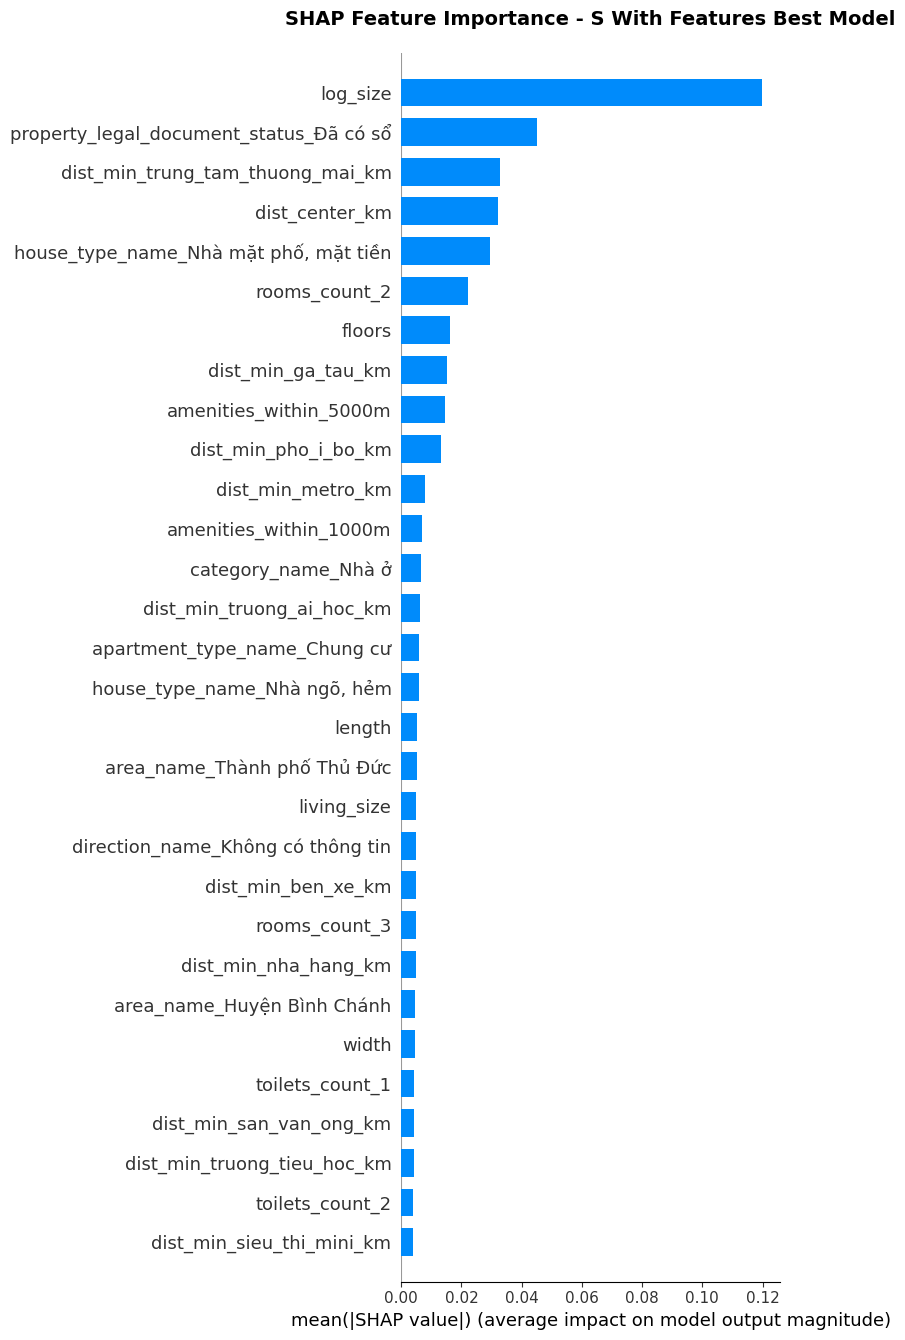


--------------------------------------------------------------------------------
Step 3: Generating Feature Importance (Dot Plot)
--------------------------------------------------------------------------------

GENERATING SHAP SUMMARY PLOT: S With Features Best Model
Plot saved to: outputs_s/_v2/shap_summary_dot.png


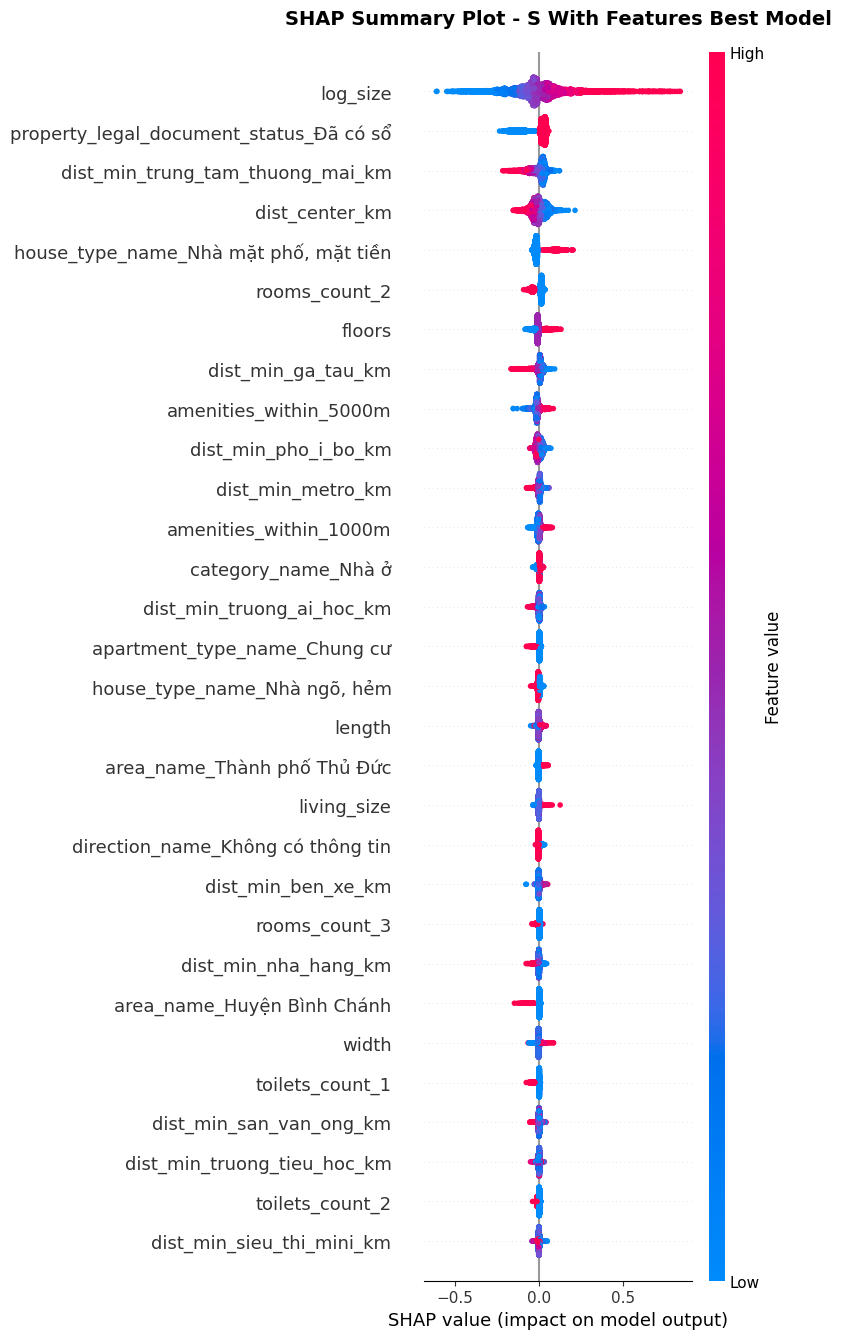


--------------------------------------------------------------------------------
Step 4: Extracting Feature Importance Table
--------------------------------------------------------------------------------

SHAP FEATURE IMPORTANCE: S With Features Best Model
 rank                                 feature  importance
    1                                log_size    0.119812
    2 property_legal_document_status_Đã có sổ    0.045252
    3        dist_min_trung_tam_thuong_mai_km    0.032900
    4                          dist_center_km    0.032250
    5   house_type_name_Nhà mặt phố, mặt tiền    0.029408
    6                           rooms_count_2    0.022039
    7                                  floors    0.016354
    8                      dist_min_ga_tau_km    0.015328
    9                  amenities_within_5000m    0.014515
   10                    dist_min_pho_i_bo_km    0.013243
   11                       dist_min_metro_km    0.007994
   12                  amenities_within_1000

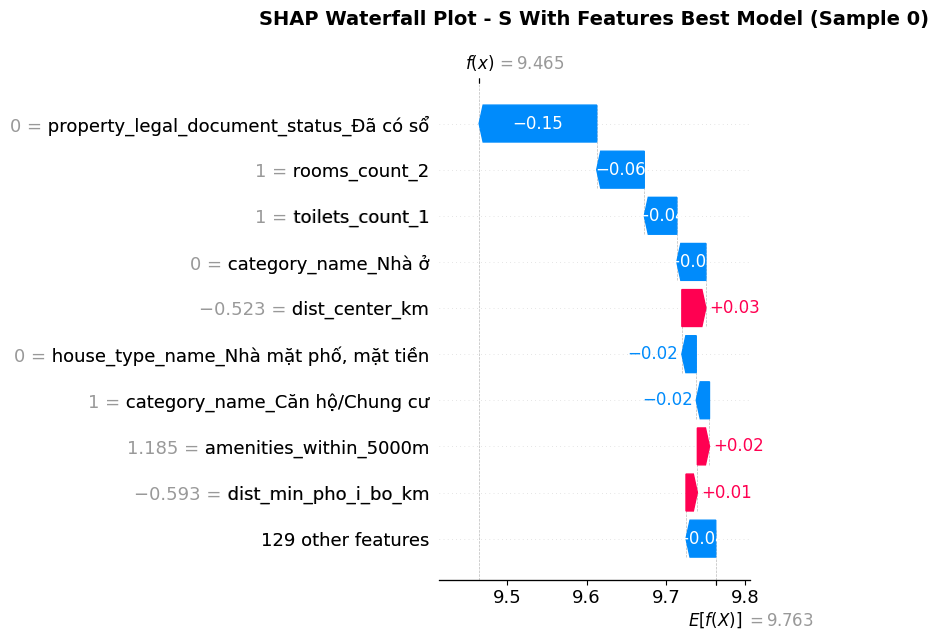


Actual log_price: 9.3424
Predicted log_price: 9.4645
Actual price: $2,200,000,000.00
Predicted price: $2,914,175,488.00
Error: $714,175,488.00

GENERATING SHAP FORCE PLOT: S With Features Best Model
Sample index: 0
Plot saved to: outputs_s/_v2/shap_force_sample_0.png


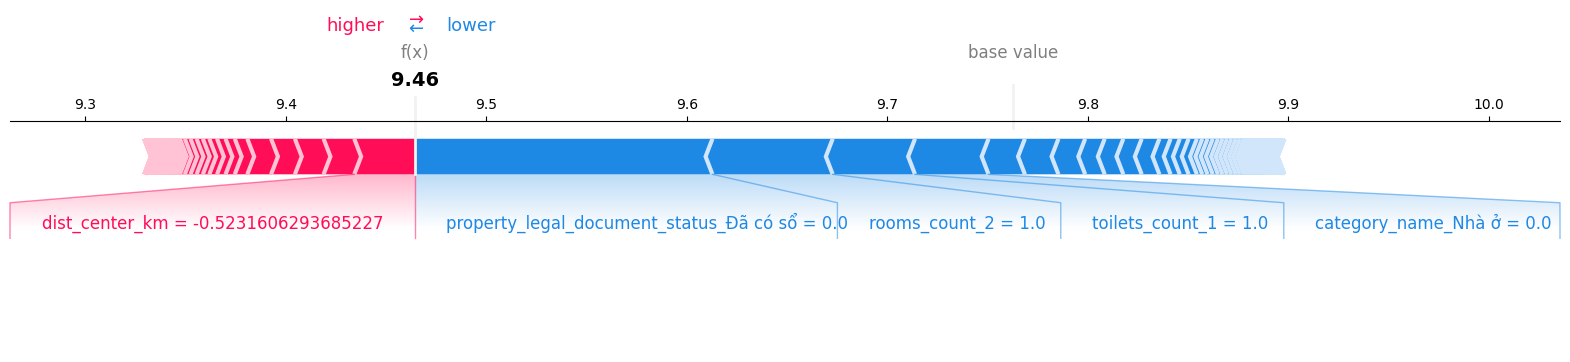


SHAP PREDICTION EXPLANATION: S With Features Best Model
Sample index: 0

                               Prediction Summary                               
Base value (average prediction): 9.7629 (log_price)
Actual log_price: 9.3424
Predicted log_price: 9.4645

Actual price: $2,200,000,000.00
Predicted price: $2,914,175,488.00
Error: $714,175,488.00

                           Top Contributing Features                            
property_legal_document_status_Đã có sổ  ↓   0.1483
rooms_count_2                            ↓   0.0600
toilets_count_1                          ↓   0.0410
category_name_Nhà ở                      ↓   0.0367
dist_center_km                           ↑   0.0303
house_type_name_Nhà mặt phố, mặt tiền    ↓   0.0181
category_name_Căn hộ/Chung cư            ↓   0.0167
amenities_within_5000m                   ↑   0.0153
dist_min_pho_i_bo_km                     ↑   0.0143
log_size                                 ↓   0.0133

                                feature  featu

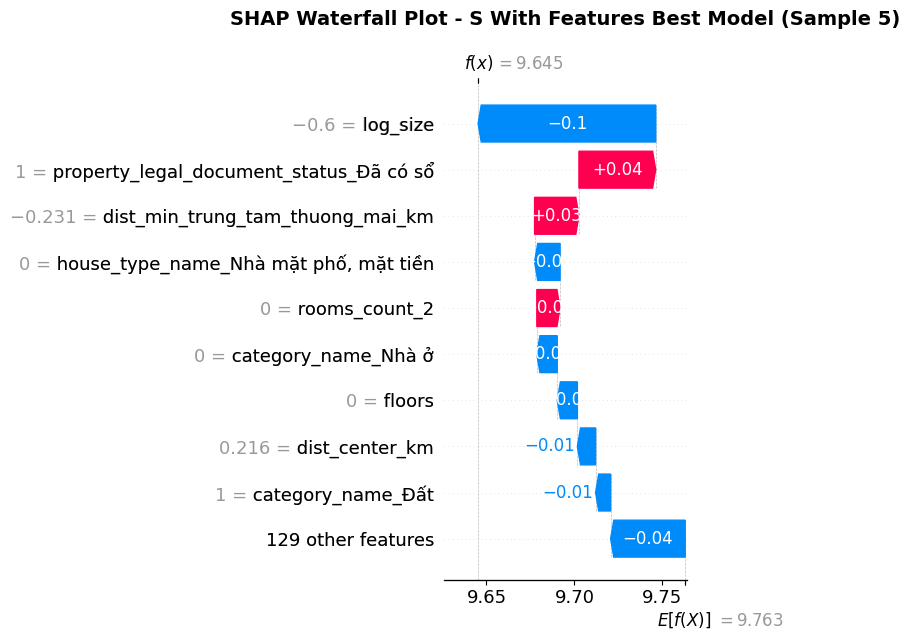


Actual log_price: 9.3010
Predicted log_price: 9.6453
Actual price: $2,000,000,000.00
Predicted price: $4,418,250,240.00
Error: $2,418,250,240.00

GENERATING SHAP FORCE PLOT: S With Features Best Model
Sample index: 5
Plot saved to: outputs_s/_v2/shap_force_sample_5.png


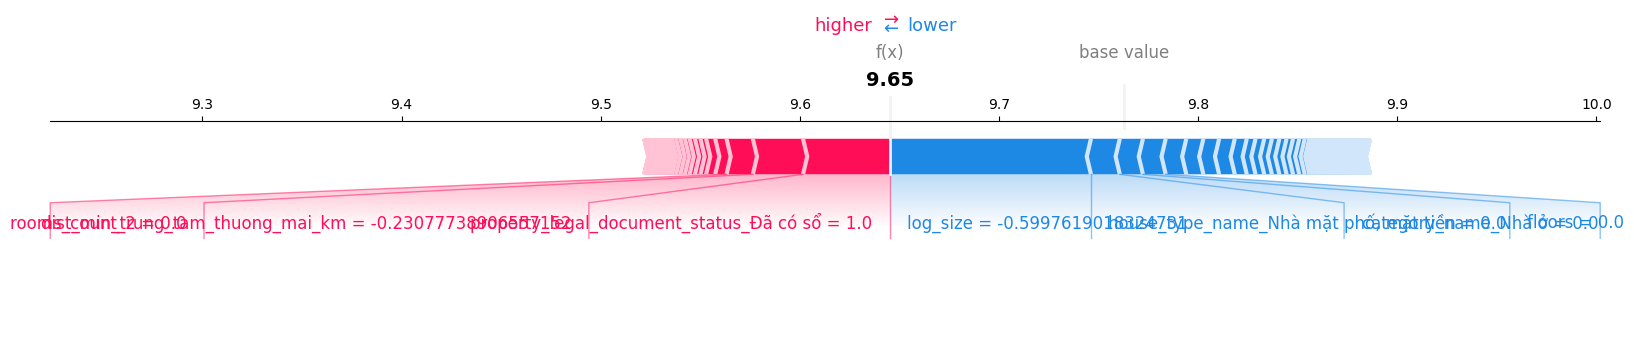


SHAP PREDICTION EXPLANATION: S With Features Best Model
Sample index: 5

                               Prediction Summary                               
Base value (average prediction): 9.7629 (log_price)
Actual log_price: 9.3010
Predicted log_price: 9.6453

Actual price: $2,000,000,000.00
Predicted price: $4,418,250,240.00
Error: $2,418,250,240.00

                           Top Contributing Features                            
log_size                                 ↓   0.1009
property_legal_document_status_Đã có sổ  ↑   0.0436
dist_min_trung_tam_thuong_mai_km         ↑   0.0252
house_type_name_Nhà mặt phố, mặt tiền    ↓   0.0145
rooms_count_2                            ↑   0.0132
category_name_Nhà ở                      ↓   0.0116
floors                                   ↓   0.0114
dist_center_km                           ↓   0.0103
category_name_Đất                        ↓   0.0085
amenities_within_5000m                   ↓   0.0079

                                feature  fea

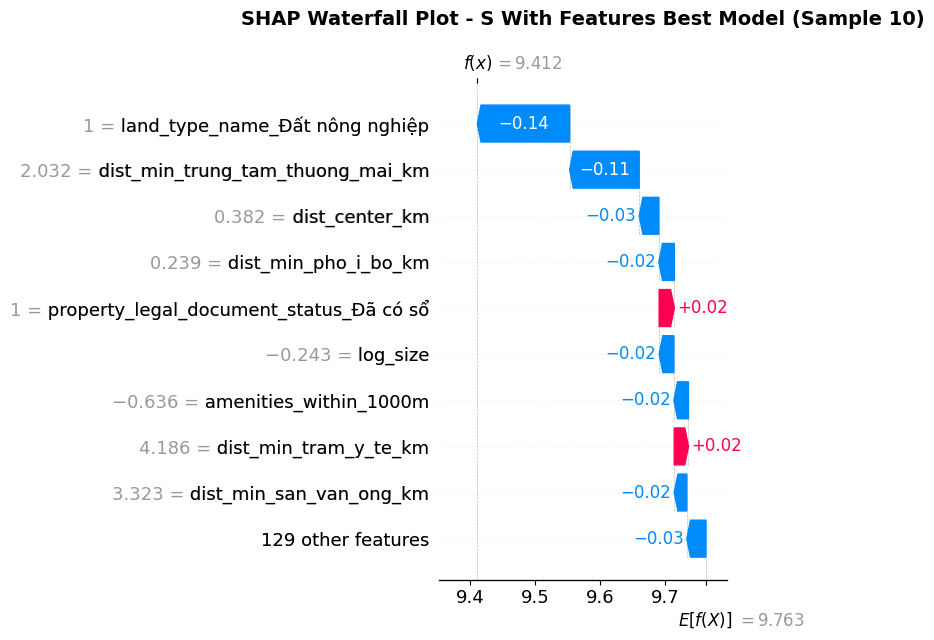


Actual log_price: 8.8062
Predicted log_price: 9.4115
Actual price: $640,000,000.00
Predicted price: $2,579,549,440.00
Error: $1,939,549,440.00

GENERATING SHAP FORCE PLOT: S With Features Best Model
Sample index: 10
Plot saved to: outputs_s/_v2/shap_force_sample_10.png


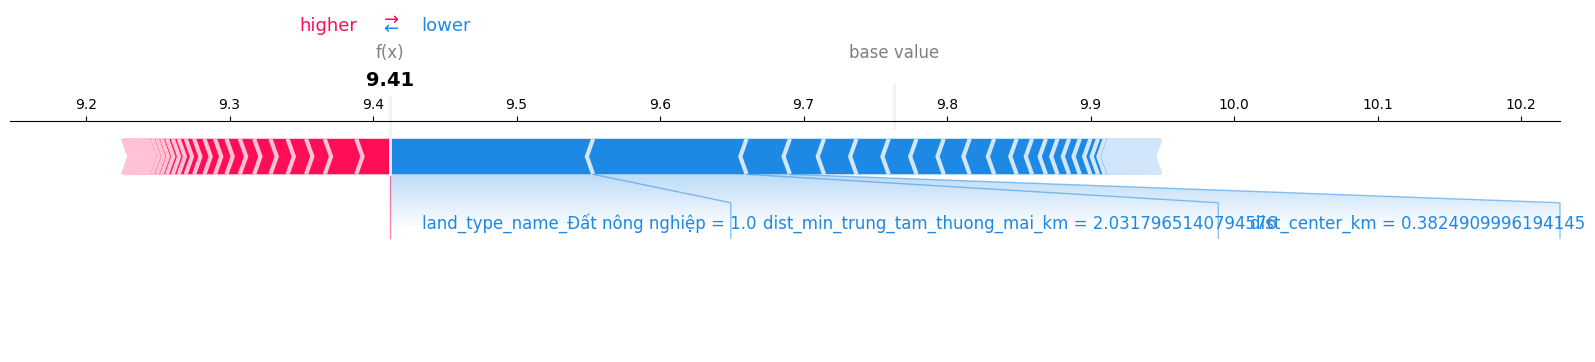


SHAP PREDICTION EXPLANATION: S With Features Best Model
Sample index: 10

                               Prediction Summary                               
Base value (average prediction): 9.7629 (log_price)
Actual log_price: 8.8062
Predicted log_price: 9.4115

Actual price: $640,000,000.00
Predicted price: $2,579,549,440.00
Error: $1,939,549,440.00

                           Top Contributing Features                            
land_type_name_Đất nông nghiệp           ↓   0.1418
dist_min_trung_tam_thuong_mai_km         ↓   0.1069
dist_center_km                           ↓   0.0302
dist_min_pho_i_bo_km                     ↓   0.0238
property_legal_document_status_Đã có sổ  ↑   0.0233
log_size                                 ↓   0.0226
amenities_within_1000m                   ↓   0.0225
dist_min_tram_y_te_km                    ↑   0.0219
dist_min_san_van_ong_km                  ↓   0.0194
amenities_within_5000m                   ↓   0.0190

                                feature  feat

In [ ]:
print("\n" + "=" * 80)
print("METHOD 2: With More Control")
print("=" * 80)

# Step 1: Load data
predictor2 = RealEstatePricePredictor(DATA_PATH)
predictor2.load_data()
predictor2.preprocess_data(test_size=0.2)

# Step 2: Load model
predictor2.load_trained_model(MODEL_PATH)

# Step 3: Run SHAP analysis
predictor2.run_shap_analysis(
    sample_indices=[0, 5, 10],  # ← Customize samples to explain
    output_dir=OUTPUT_DIR + '_v2',
    max_features=30              # ← Customize number of features
)

print(f"\n✓ Complete! Check '{OUTPUT_DIR}_v2/' for results")

In [ ]:
DATA_PATH = os.path.join(TRANSFORM_DATA_DIR, 'u_listing_with_features.csv')
MODEL_PATH = os.path.join(MODELS_DIR, "u_with_features_best_model.pkl")
OUTPUT_DIR = "outputs_u/"

In [ ]:
print("\n" + "=" * 80)
print("METHOD 2: With More Control")
print("=" * 80)

# Step 1: Load data
predictor2 = RealEstatePricePredictor(DATA_PATH)
predictor2.load_data()
predictor2.preprocess_data(test_size=0.2)

# Step 2: Load model
predictor2.load_trained_model(MODEL_PATH)

# Step 3: Run SHAP analysis
predictor2.run_shap_analysis(
    sample_indices=[0, 5, 10],  # ← Customize samples to explain
    output_dir=OUTPUT_DIR + '_v2',
    max_features=30              # ← Customize number of features
)

print(f"\n✓ Complete! Check '{OUTPUT_DIR}_v2/' for results")


METHOD 2: With More Control
LOADING DATA
Dataset shape: (37871, 49)

Target variable (log_price) statistics:
count    37871.000000
mean         6.966395
std          0.471781
min          0.000000
25%          6.633468
50%          6.875061
75%          7.217484
max         11.414973
Name: log_price, dtype: float64

Missing values summary:
floornumber       36348
floors            33346
living_size       33037
length            30545
width             30503
is_main_street    10596
area_name             1
log_size              1
dtype: int64

FEATURE DETECTION
Numeric features (36): ['floornumber', 'floors', 'length', 'living_size', 'width', 'deposit', 'log_size', 'is_good_room', 'dist_center_km', 'dist_min_cho_km', 'dist_min_sieu_thi_km', 'dist_min_sieu_thi_mini_km', 'dist_min_cua_hang_tien_loi_km', 'dist_min_truong_mam_non_km', 'dist_min_truong_tieu_hoc_km', 'dist_min_truong_thpt_km', 'dist_min_truong_ai_hoc_km', 'dist_min_benh_vien_km', 'dist_min_tram_y_te_km', 'dist_min_cong_vien_k

In [ ]:
!zip -r output_s.zip outputs_s/

In [ ]:
!zip -r output_u.zip outputs_u/